In [30]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

In [75]:
mnist_train = pd.read_csv("archive/mnist_train.csv")
mnist_test = pd.read_csv("archive/mnist_test.csv")

In [32]:
mnist_train

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
y_train = mnist_train["label"].copy().to_numpy()
X_train = mnist_train.drop(columns=["label"]).to_numpy()

print("The training digits data:\n", X_train)
print("Digit labels: ", y_train)

# Similarly for the test set
y_test = mnist_test["label"].copy().to_numpy()
X_test = mnist_test.drop(columns=["label"]).to_numpy()

The training digits data:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Digit labels:  [5 0 4 ... 5 6 8]


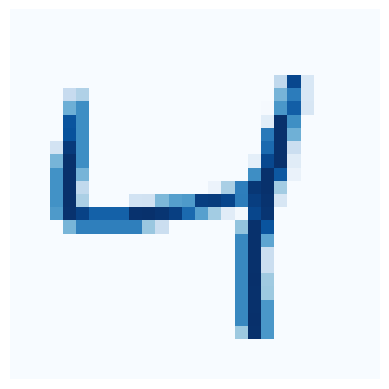

(784,)

In [77]:
some_digit_data = X_train[2]
some_digit_image = some_digit_data.reshape(28, 28)

# imshow plots the matrix
plt.imshow(some_digit_image, cmap=plt.cm.Blues)
plt.axis("off")
plt.show()
some_digit_data.shape

In [88]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier( n_neighbors=3)

# train the classifier
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

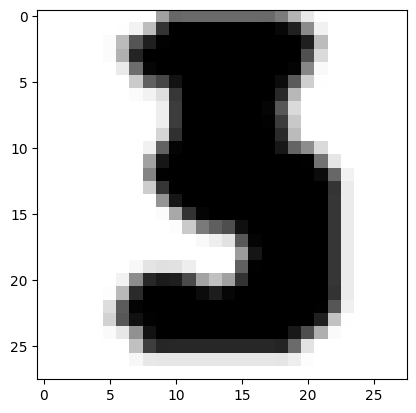

In [83]:
from PIL import Image
import cv2
test1 = Image.open("3.png")
test1 = test1.resize((28, 28))
plt.imshow(test1)
plt.show()

In [84]:
number = 9

img = test1.convert('L')

#print np.array(img)
img_arr = np.array(img)

#print img_arr.flatten()

WIDTH, HEIGHT = img.size

data = list(img.getdata()) # convert image data to a list of integers
# convert that to 2D list (list of lists of integers)
data = [data[offset:offset+WIDTH] for offset in range(0, WIDTH*HEIGHT, WIDTH)]

# At this point the image's pixels are all in memory and can be accessed
# individually using data[row][col].

# For example:
# for row in data:
#     print(' '.join('{:3}'.format(value) for value in row))
data = np.array(data)
data = data.flatten().reshape(1, -1)
data.shape

(1, 784)

In [89]:


# Display the image arra
knn.predict(data)


array([0])

In [90]:
import matplotlib.pyplot as plt

# Import datasets, classifiers and performance metrics
from sklearn import datasets, svm, metrics
from sklearn.model_selection import train_test_split

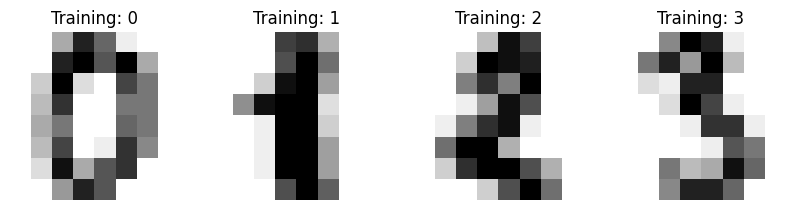

In [91]:
digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

In [92]:
# flatten the images
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Create a classifier: a support vector classifier
clf = svm.SVC(gamma=0.001)

# Split data into 50% train and 50% test subsets
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.5, shuffle=False
)

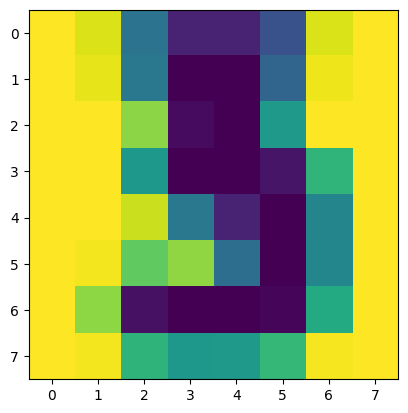

In [93]:
from PIL import Image
import numpy as np
from sklearn.preprocessing import scale

# Load the image
image = Image.open('3.png')

# Convert to grayscale
image = image.convert('L')

# Resize to 8x8 pixels
image = image.resize((8, 8))
plt.imshow(image)
plt.show()

In [94]:
# Flatten the image into a 1-dimensional array
image_array = np.ravel(np.array(image))
print(image_array.shape)

image_array = image_array/16
image_array = image_array.reshape(1, -1)
image_array.shape

(64,)


(1, 64)

In [95]:
# Learn the digits on the train subset
clf.fit(X_train, y_train)

SVC(gamma=0.001)

In [96]:
# Predict the value of the digit on the test subset
clf.predict(image_array)


array([1])